

#### **Machine Learning and Data Science Research Project - Milestone 2**

**Project:** Reinforcement Learning for Optimal Execution 

**Author:** Robert de Witt (CID: 02541719)

**Research Goals**

This project investigates whether reinforcement learning–driven execution policies can reduce slippage relative to the arrival price (mid-price) and other benchmarks. We will explore and apply existing researched reinforcement learning techniques and novel approaches to find a superior performing trading strategy.

The problem statement can be formally defined as:

* Slippage per order $i$

$$
  s_i = \text{side}_i \cdot p_{0,i} - \bar p_{\mathrm{order},i},
  \quad
  p_{0,i} = \frac{p^{\mathrm{bid}}_i[t_0] + p^{\mathrm{ask}}_i[t_0]}{2}.
$$

* Where $side_i = 1$ if a buy order, $side_i = -1$ if a sell order and $\bar{p}_{{order},i} = \sum^{i<=H}_{i=1} \frac{p_i * q_i}{Q_i}$, and $q_i$ is the filled quantity per child order, $Q_i$ is the executed total executed quantity.

* The primary objective is to minimize notionally weighted slippage for all executed orders:

$$  \min \bar s_{\mathrm{wtd}}
  \;=\;\sum_{i=1}^n s_i \,\bigl(\bar p_{\mathrm{order},i}\,Q_i\bigr).
$$

* Note: In the final project we will also include slippages to market interval VWAP for the order duration and a hypothetical "best" price where we trade at 1.5x the target during the best prices of the order horizon. 

**Overview of Gym workflow**

**Goals**

We will try a number of agents based on multiple papers, as well as some novel approaches to reinforcement learning such as Quality Diversity [1-3] and MAP-Elites approaches [4-6]. All agents will be tuned for the same purpose. To train and trial the RL agents, a realistic gym (back-testing) environment must be established. The gym will accept train, test and optional validation sets of random orders across a series of dates and stocks, each with different horizons and percentages of average daily volumes. In the final project, we will also ensure these orders are diversified across a number of market regimes to ensure robustness or the resulting agent results. For each of the orders, we will train, test and validate each of the agents. We will compare all agents performance across a large number market segments and benchmarks including arrival price, VWAP, completion rate, opportunity cost, variation of trade rates versus target, hypothetical best price, etc. to confirm the superiority of the best agent.

Detailed explanations are in the document covering:

* Order Generation
* Order Characteristics
* RL Environment
* Trading Simulation
* Agent being tested 
* Agent Summary Statistics

In [1]:
from mkt_data_yfinance import MarketDataLoader as mdl
import render_plots
import pandas as pd
from optimal_execution_env import MultiOrderExecutionEnv
from order_generator import OrderGenerator
from notebook_logging_setup import quick_setup
from gymnasium.utils.env_checker import check_env
from stable_baselines3 import PPO
from gymnasium.wrappers import TimeLimit
import torch
from stable_baselines3.common.vec_env import SubprocVecEnv
import numpy as np

quick_setup(debug=False)

Logging configured at INFO level


In [2]:
max_trading_rate = 0.8
max_order_size_in_adv_pct = 0.1
tickers = ['AAPL','MSFT','GOOGL','AMZN','TSLA','NVDA','JPM','V','JNJ','DIS']
md = mdl()
stock_df_list = md.load_data(tickers)
stock_df_list = md.pre_process_data(stock_df_list)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
# print first 3 rows of each stock dataframe
#for stock in stock_df_list:
#    print(stock_df_list[stock].head(-3))
# Create the environment

**Order Generation**

The order generation process creates a set of trading orders with the following characteristics:
1.  For each order, a random stock is selected from the available universe, and its Average Daily Volume (ADV) is calculated as the mean of daily trading volumes.
2. The order size is determined by sampling a random percentage of ADV between min_adv_pct and max_adv_pct, scaled by the time horizon (as a fraction of the trading day). This ensures that larger orders are spread over longer time periods and that the orders can complete within the time horizon given 
3. The execution window is defined by randomly selecting a start time and a time horizon (in minutes) between min_time_horizon and max_time_horizon, with the end time being start_time + time_horizon.
4. Each order is assigned a random side (buy/sell) and its quantity is rounded to the nearest integer, with safeguards to prevent zero-sized orders. The resulting orders are then used to train or evaluate the execution strategy in the reinforcement learning environment.
5. For simplicity's sake, we will not apply order constraints such as limit prices or volume limits, we will assume lit market trading only and we will not worry about auctions.

In [4]:
train_orders_df = OrderGenerator(stock_df_list=stock_df_list, market_data=md, debug=False, max_adv_pct=max_order_size_in_adv_pct, num_orders=50000).get_orders()
test_orders_df = OrderGenerator(stock_df_list=stock_df_list, market_data=md, debug=False, max_adv_pct=max_order_size_in_adv_pct, num_orders=20000).get_orders()

3 Sample Train Orders:
Sample Train (1): ticker: DIS order_qty: 160096 adv_pct: 1.93% adv: 8,314,175 start_time: 33 end_time: 371 time_horizon: 338 side: buy intra_order_return: -0.010499031282961369 today_volatility: 0.02232135273516178 
Sample Train (2): ticker: AMZN order_qty: 1599175 adv_pct: 5.22% adv: 30,635,764 start_time: 3 end_time: 384 time_horizon: 381 side: sell intra_order_return: -0.005882895085960627 today_volatility: 0.02529389038681984 
Sample Train (3): ticker: JPM order_qty: 129195 adv_pct: 2.17% adv: 5,956,588 start_time: 245 end_time: 342 time_horizon: 97 side: sell intra_order_return: -0.007663199678063393 today_volatility: 0.017018143087625504 
3 Sample Test Orders:
Sample Test (1): ticker: TSLA order_qty: 713842 adv_pct: 0.49% adv: 146,642,480 start_time: 362 end_time: 388 time_horizon: 26 side: buy intra_order_return: 0.03533658757805824 today_volatility: 0.187913715839386 
Sample Test (2): ticker: GOOGL order_qty: 799653 adv_pct: 2.71% adv: 29,456,566 start_ti

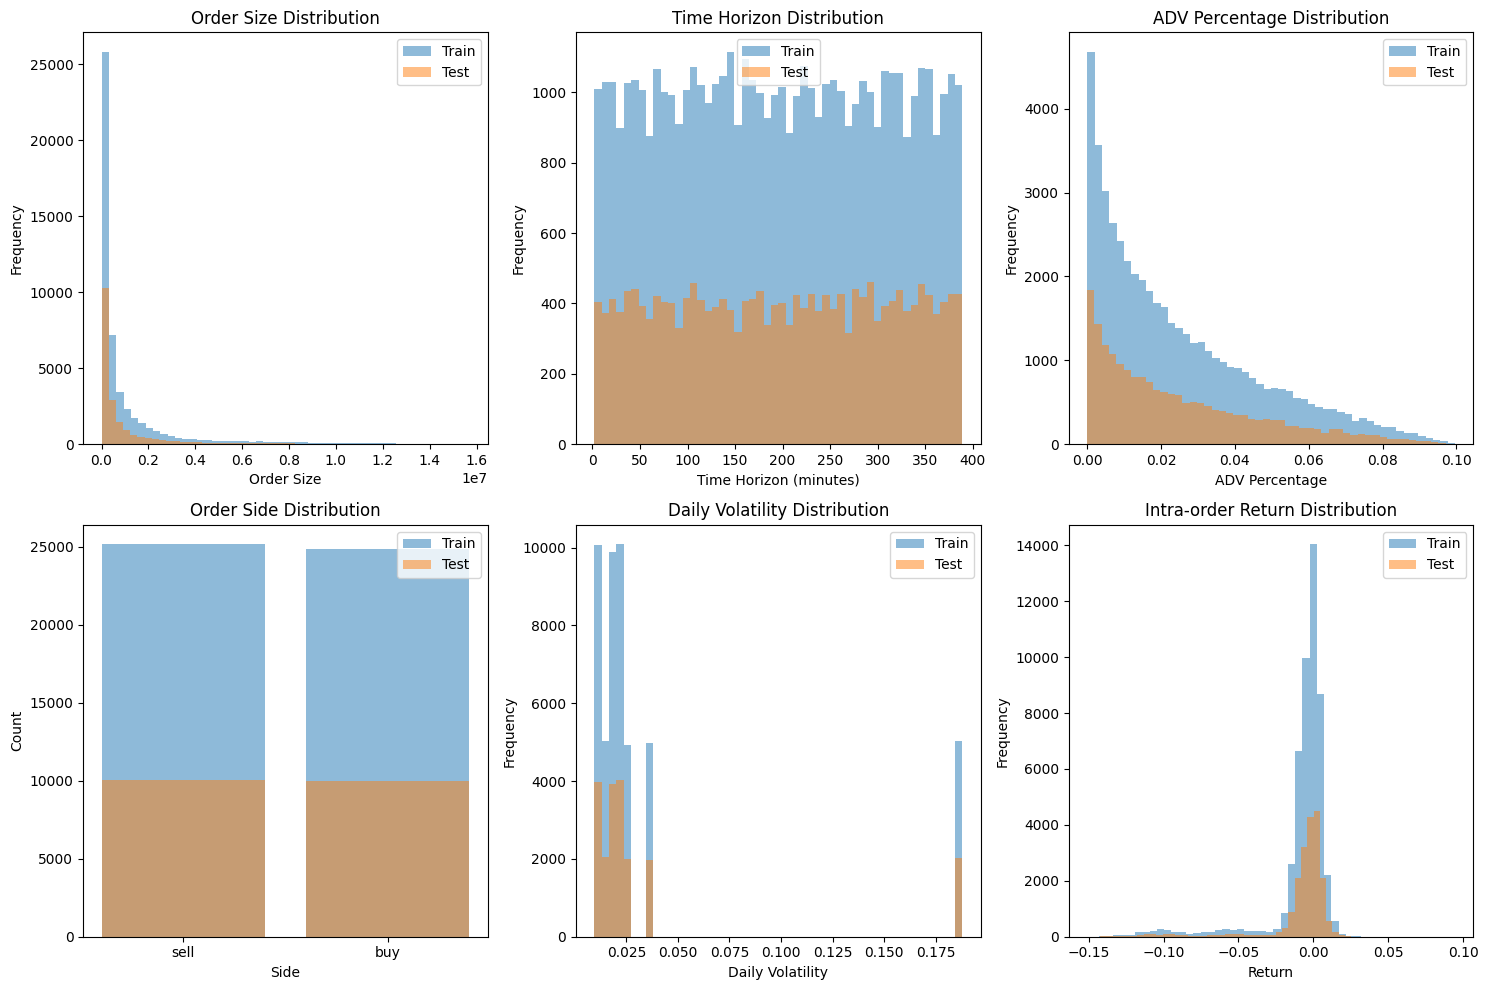

In [17]:
# print orders dataframe in single line per order
render_plots.display_order_info(train_orders_df, name='Sample Train', num_orders=3)
render_plots.display_order_info(test_orders_df, name='Sample Test', num_orders=3)
render_plots.plot_order_histograms(train_orders_df, test_orders_df)


**Order Characteristics**

Most of the orders are naturally stratified on size, stock, side and horizon. In the next version of the order generator, we will take a much wider selection of stocks to capture different levels of liquidity, volatility, trending markets, shocks, stable markets, etc.

**RL Environment**

In the current setup the agent’s **state** at each step is a 14-dimensional real vector  
$$
s_t = \bigl[p_t^{\rm mid},\,V_t,\,T - t,\,q_t,\,\alpha,\,x,\,f,\,m,\,\delta,\,A,\,p_0,\,r,\,v^{(1)},\,v^{(5)}\bigr],
$$  
where it sees the current mid-price, market volume, time and shares remaining, target participation rate, trading signals, last fill and trade stats, arrival price, regime and short/long‐term volatilities.  Its **action**  
$$
a_t \in \{0,\,0.05,\,0.10,\,0.15,\,0.25,\,0.50,\,0.75\}
$$  
is “trade this fraction of today’s volume,” so the env executes  
$$
\Delta q_t = \min(a_t\,V_t,\;q_t)
$$  
shares (and updates  
$$
q_{t+1} = q_t - \Delta q_t
$$  
and the running VWAP).  Episodes end when either all shares are filled or the time horizon is hit, a large penalty is applied if the order does not complete.


**Trading Simulation**

In order to realistically simulate market behaviour, each trade needs to create an impact on price, and successive trades must propagate impact to the next order and so on. Rather than consider the nuance of trade by trade, limit and market orders and order books which require many assumptions and complex limit order book simulators, we focus on minutely percentage of volume trading. This allows to focus on building an optimal scheduling algorithm and removes the granular complexities of limit order books, order types and venue types.

For minutely impact level impact estimations have utilized the transient impact model 2 from Bouchaud's book Trades, Quotes and Prices [7] which is parameterized with intuitive default values for this update and assumes the 1 minute trade impact follows square root.  We account for gaps between 1 minute trade intervals allowing for more accurate decay. In the final report, we will include a calibrated version of this model based on the trades observed via Bank of America's trade data. 


**Linear Transient‐Impact (Propagator) Model [7]**  
$$
r_t \;=\;\sum_{t'<t} G(t - t')\,\epsilon_{t'} \;+\;\eta_t,
$$
where $r_t = P_t - P_{t-1}$ is the mid-price return, $\epsilon_{t'}\!=\pm1$ the sign of the trade at time $t'$, $G(\tau)$ the propagator kernel, and $\eta_t$ an uncorrelated noise term.  

In our case we do allow for non-uniformity of time steps between trades so we modify to consider the $t_{\Delta}$:

$$
\lambda(\Delta t)
\;=\;
\exp\!\Bigl(-\frac{\Delta t}{\tau}\Bigr),
\quad
\Delta I_t
\;=\;
Y\,\sigma\,\sqrt{\frac{q_t}{V}},
$$

$$
I_t
\;=\;
\lambda(\Delta t)\,I_{t-1}
\;+\;
\Delta I_t,
$$

$$
p_t^{\mathrm{fill}}
\;=\;
p_t^{\mathrm{vwap}}
\bigl(1 \;+\; s\,I_t\bigr).
$$

In [6]:
# generate the execution environments for training
train_execution_env = MultiOrderExecutionEnv(stock_df_list=stock_df_list, orders_df=train_orders_df, impact_coef=1, num_envs=1, decay_rate=5, window_size=1, min_rate=0, max_rate=max_trading_rate)
max_horizon = int(train_orders_df["time_horizon"].max())
train_env = TimeLimit(train_execution_env, max_episode_steps=max_horizon)
check_env(train_env)
# generate the execution environments for testing
test_execution_env = MultiOrderExecutionEnv(stock_df_list=stock_df_list, orders_df=test_orders_df, impact_coef=1, num_envs=1, decay_rate=5, window_size=1, min_rate=0, max_rate=max_trading_rate)
max_horizon = int(test_orders_df["time_horizon"].max())
test_env = TimeLimit(test_execution_env, max_episode_steps=max_horizon)
check_env(test_env)

2025-06-16 07:47:01 - optimal_execution_env - INFO - Using device: mps


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/gymnasium/utils/env_checker.py:384: UserWarning: WARN: The environment (<TimeLimit<MultiOrderExecutionEnv instance>>) is different from the unwrapped version (<MultiOrderExecutionEnv instance>). This could effect the environment checker as the environment most likely has a wrapper applied to it. We recommend using the raw environment for `check_env` using `env.unwrapped`.
  logger.warn(


2025-06-16 07:47:02 - optimal_execution_env - INFO - Using device: mps


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/gymnasium/utils/env_checker.py:434: UserWarning: WARN: Not able to test alternative render modes due to the environment not having a spec. Try instantiating the environment through `gymnasium.make`
  logger.warn(


**Agents**

This is a basic "out of the box" PPO agent with no tuning or modification. The purpose is the allow for a constant at the environment is being bult.

In [7]:
model = PPO("MlpPolicy", train_env, device="cpu", verbose=0, learning_rate=3e-4, 
            n_steps=512, batch_size=256, n_epochs=10,gamma=0.99, gae_lambda=0.95, clip_range=0.2,
            policy_kwargs=dict(net_arch=dict(pi=[256, 256], vf=[256, 256]), activation_fn=torch.nn.ReLU))
model.learn(total_timesteps=2000)
model.save("ppo_multiorder_exec")

In [8]:
model = PPO.load("ppo_multiorder_exec")
train_orders = train_execution_env.execute_orders(model=model,num_episodes=10)
test_orders = test_execution_env.execute_orders(model=model,num_episodes=10)

In [9]:
orders_by_minute_df = pd.DataFrame(columns=['episode','current_step', 'order_idx', 'ticker', 'side', 'order_qty', 'adv_pct', 'start_time', 'end_time', 'time_horizon'])
print(f"Executed {len(test_orders)} orders:")
for episode in test_orders:
    for order in episode:
        orders_by_minute_df = pd.concat([orders_by_minute_df, pd.DataFrame([order])], ignore_index=True)

Executed 10 orders:


/var/folders/mn/sstp0slh8xjckg0059bj70p80000gp/T/ipykernel_31949/3841225797.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  orders_by_minute_df = pd.concat([orders_by_minute_df, pd.DataFrame([order])], ignore_index=True)


In [16]:
# To display a single order's time steps
pd.set_option('display.max_columns', None)
orders_by_minute_df[orders_by_minute_df['episode'] == 1]

,episode,current_step,order_idx,ticker,side,order_qty,adv_pct,start_time,end_time,time_horizon,arrival_price,order_vwap,shares_remaining,immediate_impact,accumulated_impact,last_fill_price,last_trade_size,vwap_price,mid_price,total_reward,current_volume,action_percentage,adv,is_finished
179,1,0,1,JPM,sell,137567,0.023095,62,163,101,261.36499,261.351868,137567.0,0.000000,0.000000,261.351868,0.0,261.351868,261.364990,0.000000,10952.0,0.00,5956588.0,NaN
180,1,0,1,JPM,sell,137567,0.023095,62,163,101,261.36499,261.256531,134829.0,0.000365,0.000365,261.256531,2738.0,261.351868,261.364990,-0.000415,10952.0,0.25,5956588.0,False
181,1,1,1,JPM,sell,137567,0.023095,62,163,101,261.36499,261.186310,130887.0,0.000438,0.000737,261.137512,3942.0,261.329987,261.309998,-0.001285,15768.0,0.25,5956588.0,False
182,1,2,1,JPM,sell,137567,0.023095,62,163,101,261.36499,260.987457,121647.0,0.000670,0.001273,260.843719,9240.0,261.176270,261.154999,-0.003280,36958.0,0.25,5956588.0,False
183,1,3,1,JPM,sell,137567,0.023095,62,163,101,261.36499,260.899292,113806.0,0.000617,0.001660,260.720245,7841.0,261.153748,261.187500,-0.005747,31363.0,0.25,5956588.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,1,96,1,JPM,sell,NaN,NaN,NaN,NaN,101,NaN,261.177948,0.0,NaN,0.000000,263.248749,0.0,263.248749,263.232483,-0.070545,8204.0,NaN,5956588.0,True
277,1,97,1,JPM,sell,NaN,NaN,NaN,NaN,101,NaN,261.177948,0.0,NaN,0.000000,263.297485,0.0,263.297485,263.299988,-0.071260,7251.0,NaN,5956588.0,True
278,1,98,1,JPM,sell,NaN,NaN,NaN,NaN,101,NaN,261.177948,0.0,NaN,0.000000,263.262512,0.0,263.262512,263.265015,-0.071976,7181.0,NaN,5956588.0,True
279,1,99,1,JPM,sell,NaN,NaN,NaN,NaN,101,NaN,261.177948,0.0,NaN,0.000000,263.254028,0.0,263.254028,263.244995,-0.072691,7014.0,NaN,5956588.0,True


**Evaluation**


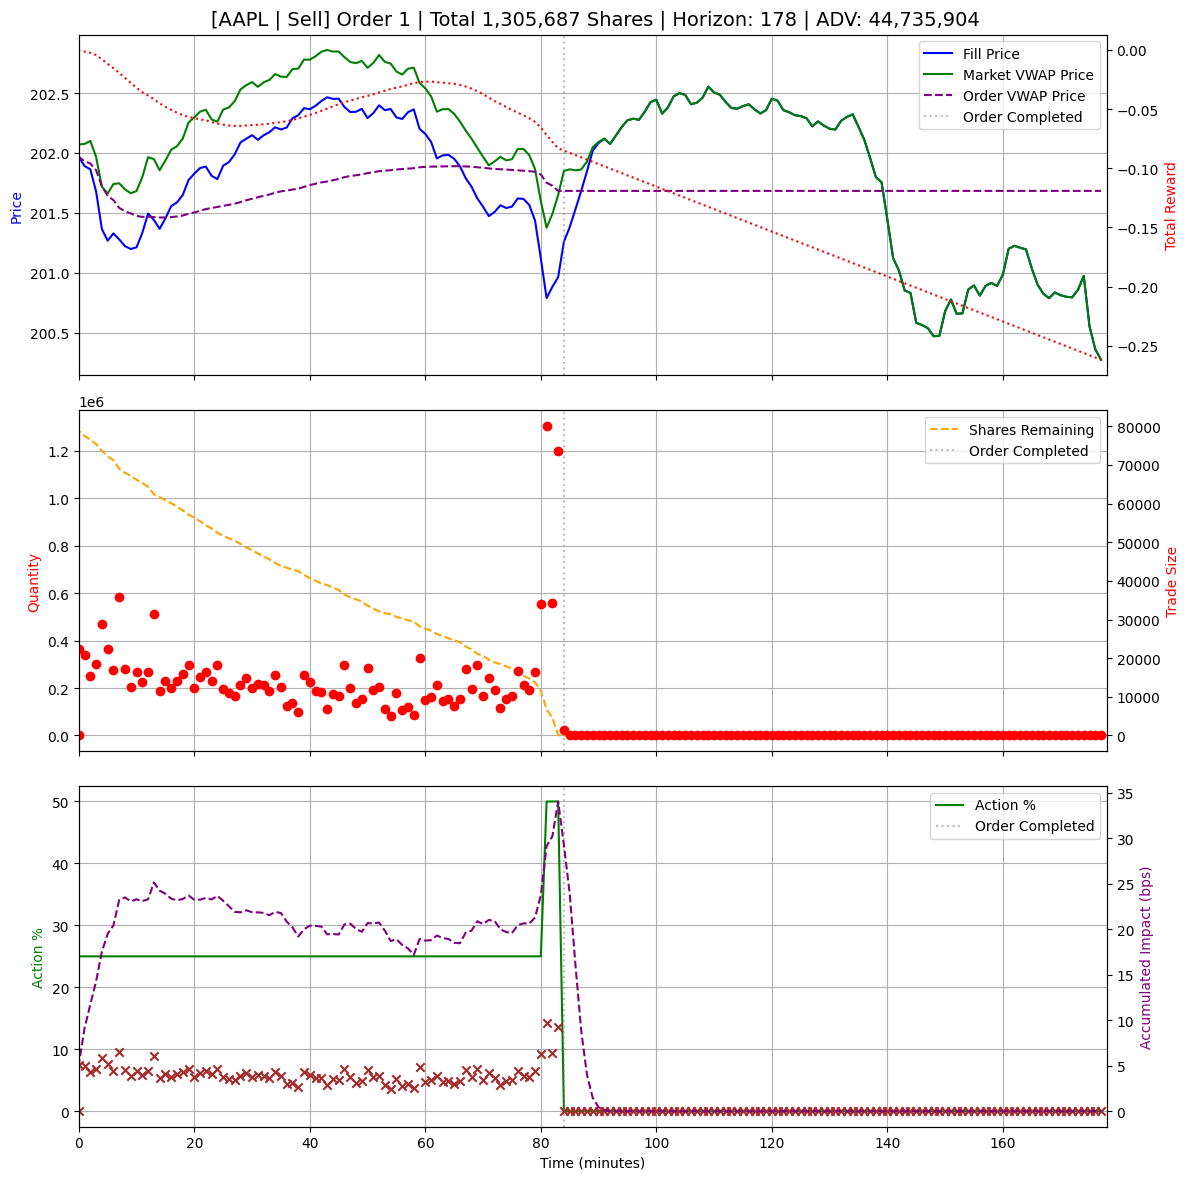


Execution Summary Table
Number of Orders - Train: 10, Test: 10
----------------------------------------------------------------------------------------------------
Metric                                   Train       Train Std            Test        Test Std
----------------------------------------------------------------------------------------------------
Weighted Slippage (bps)                -154.04          155.49           34.22           27.95
Weighted Duration Ratio                   0.23            0.10            0.21            0.13
Weighted Intra-Order Return (bps)         -636.44          364.43          -53.46           62.50
Mean Reward (bps)                    -21388.51        34046.16        -5195.64         6586.72
Mean Action %                            28.57           10.63           28.30           10.90
Note: Slippage and Returns are in basis points (bps)
      Duration Ratio is completion time / total horizon
      Action percentages are in %


In [14]:
render_plots.plot_orders(test_orders, num_orders=1)
render_plots.create_execution_summary_table(train_orders=train_orders, test_orders=test_orders, trim=0.01)

Note: there is an error in the dislayed reward calculation.

**Execution Summmary Table Observations**

At this stage, we have built the foundations of what we hope will be a robust framework to extend for trialling agents. it is clear that we need to focus on tuning the agents and the environment. Despite having high impact on price, the agent continually chooses much higher percentages of volume causing the orders to complete within 20% of the order horizons on average for no perceived price advantage. We will experiment with penalizing the agent for deviating too highly from an expected percentage of volume and/or narrowing the action space to close to the target POV. We wll also add VWAP and an optimal arrival benchmark to encourage more temporal exploration. We also look forward to looking throgh the to-dos below and making them happen in the final project.

**References**

[1] Lehman, J. & Stanley, K. O. (2011). _Evolving a Diversity of Creatures through Novelty Search and Local Competition_. In Proceedings of the 13th Genetic and Evolutionary Computation Conference (GECCO) (pp. 211–218). ACM.

[2] Pugh, J. K., Soros, L. B., & Stanley, K. O. (2016). _Quality Diversity: A New Frontier for Evolutionary Computation_. Frontiers in Robotics and AI, 3, 40.

[3] Cully, A. & Demiris, Y. (2017). _Quality and Diversity Optimization: A Unifying Modular Framework_. arXiv:1708.09251.

[4] Mouret, J.-B. & Clune, J. (2015). _Illuminating Search Spaces by Mapping Elites_. arXiv:1504.04909.

[5] Cully, A., Clune, J., Tarapore, D., & Mouret, J.-B. (2015). _Robots That Can Adapt Like Animals_. Nature, 521(7553), 503–507.

[6] Gaier, A., Asteroth, A., & Mouret, J.-B. (2017). _Data-Efficient Exploration, Optimization, and Modeling of Diverse Designs through Surrogate-Assisted Illumination_. arXiv:1702.03713.

[7] Bouchaud, J.-P., Bonart, J., Donier, J., & Gould, M. (2018). _The Propagator Model_. In Trades, Quotes and Prices: Financial Markets Under the Microscope (pp. 252–253). Cambridge University Press.

[8] Tóth, B., Lempérière, Y., Deremble, C., de Lataillade, J., Kockelkoren, J., & Bouchaud, J.-P. (2011). _Anomalous price impact and the critical nature of liquidity in financial markets_. Physical Review X, 1(2), 021006.









**Appendix**

To-dos for the final project:

* Create parallelizable agent testing framework
* Why does the reward change at the end of the time horizon?
* Implement multiple agents from papers and using Quality Diveristy and MAP methods
* Train/Test split based on date ranges and new unseen symbols 
* Could we use unfilled quanity/EHV as a penalty to ensure it doesn't get too far behind so it can complete?
* Find and break out days by different regimes, e.g. high volatility, low volatility, trending, mean reverting, shocks, stable markets, etc. add these to the gym
* Add hypothetical slippage to the ultimate best price for the horizon to indicate opportunity cost
* Consider more advanced propagator models such as the 6-event propagator model (ch. 14 of Trades, Quotes and Prices)
* Utilize real order data for the impact model callibrations, tau, Y
* Linear versus square root for 1 minute impact?
* Make volume profiles to scale volume and remove auctions, remove special days
* Add longer look-back on market data
* TODO: fix the warnings in check env
* TODO: fix warnings in geneerate orders
* TODO: refactor optimal execuion env
* TODO: add % of incomplete orders 